# Visual Diagnostics and Stationarity Testing

**Docker image**: `ml4t`

This notebook demonstrates the complete diagnostic workflow for financial
time series: visual inspection, stationarity tests, autocorrelation analysis,
and rolling diagnostic features.

**Learning Objectives**:
- Perform visual diagnostics (time series plot, ACF/PACF, Q-Q plot)
- Test stationarity using ADF and KPSS with the joint decision matrix
- Compute Ljung-Box test for residual autocorrelation
- Build rolling ADF/KPSS statistics as time-varying features

**Book Reference**: Chapter 9, Section 9.1 (Diagnostics and Stationarity Features)

**Prerequisites**: None — this is the starting point for Ch9.

In [1]:
"""Visual Diagnostics and Stationarity Testing — the diagnostic workflow."""

import warnings

warnings.filterwarnings("ignore")

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from ml4t.diagnostic.evaluation.autocorrelation import analyze_autocorrelation
from ml4t.diagnostic.evaluation.distribution import analyze_distribution
from ml4t.diagnostic.evaluation.stationarity import analyze_stationarity
from ml4t.diagnostic.evaluation.volatility import arch_lm_test
from scipy.stats import norm, probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss

from data import load_etfs, load_macro

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2000-01-01"
END_DATE = "2024-12-31"
ROLLING_WINDOW = 252

## Load Data

SPY (S&P 500 ETF) for trending price series and VIX for a mean-reverting
volatility series — contrasting stationarity behaviors.

In [3]:
etfs = load_etfs(symbols=["SPY"])
sp500 = etfs.select(["timestamp", "close"]).rename({"close": "value"}).sort("timestamp")

macro = load_macro()
vix = (
    macro.select(["timestamp", "vixcls"]).drop_nulls().rename({"vixcls": "value"}).sort("timestamp")
)

START = datetime.strptime(START_DATE, "%Y-%m-%d")
END = datetime.strptime(END_DATE, "%Y-%m-%d")
sp500 = sp500.filter((pl.col("timestamp") >= START) & (pl.col("timestamp") <= END))
vix = vix.filter((pl.col("timestamp") >= START) & (pl.col("timestamp") <= END))

# Add returns
sp500 = sp500.with_columns(returns=pl.col("value").pct_change() * 100).drop_nulls()

sp500_pd = sp500.to_pandas().set_index("timestamp")
vix_pd = vix.to_pandas().set_index("timestamp")
returns = sp500_pd["returns"]

print(
    f"S&P 500: {len(sp500_pd):,} obs ({sp500_pd.index.min().date()} to {sp500_pd.index.max().date()})"
)
print(f"VIX: {len(vix_pd):,} obs ({vix_pd.index.min().date()} to {vix_pd.index.max().date()})")

S&P 500: 4,780 obs (2006-01-04 to 2024-12-31)
VIX: 9,130 obs (2000-01-03 to 2024-12-31)


## Visual Inspection

Start with four plots that reveal trend, volatility clustering, and
distributional properties at a glance.

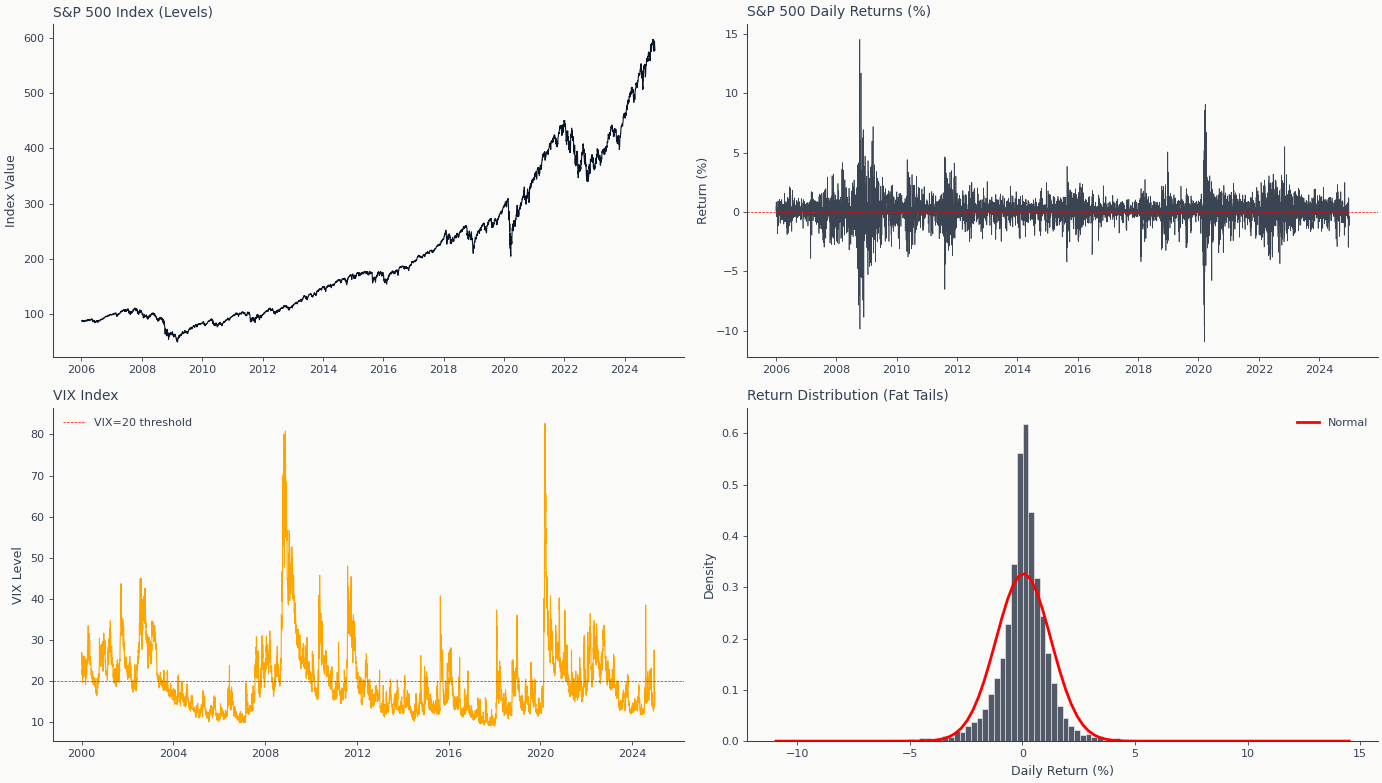

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ax = axes[0, 0]
ax.plot(sp500_pd.index, sp500_pd["value"].values, linewidth=0.8)
ax.set_title("S&P 500 Index (Levels)")
ax.set_ylabel("Index Value")

ax = axes[0, 1]
ax.plot(returns.index, returns.values, linewidth=0.5, alpha=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("S&P 500 Daily Returns (%)")
ax.set_ylabel("Return (%)")

ax = axes[1, 0]
ax.plot(vix_pd.index, vix_pd["value"].values, linewidth=0.8, color="orange")
ax.axhline(20, color="red", linestyle="--", linewidth=0.5, label="VIX=20 threshold")
ax.set_title("VIX Index")
ax.set_ylabel("VIX Level")
ax.legend()

ax = axes[1, 1]
ax.hist(returns.values, bins=100, density=True, alpha=0.7, edgecolor="white")
x = np.linspace(returns.min(), returns.max(), 100)
ax.plot(x, norm.pdf(x, returns.mean(), returns.std()), "r-", linewidth=2, label="Normal")
ax.set_title("Return Distribution (Fat Tails)")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

## Stationarity Testing: ADF + KPSS Decision Matrix

Using two tests with opposite null hypotheses provides robust conclusions:

| ADF Result | KPSS Result | Conclusion |
|:-----------|:------------|:-----------|
| Reject H0 | Fail to reject H0 | Stationary (both agree) |
| Fail to reject H0 | Reject H0 | Non-stationary (both agree) |
| Reject H0 | Reject H0 | Trend-stationary |
| Fail to reject H0 | Fail to reject H0 | Inconclusive |

In [5]:
def run_stationarity_tests(series: pd.Series, name: str) -> dict:
    """Run ADF and KPSS tests with joint interpretation."""
    series = series.dropna()

    adf_stat, adf_pval, adf_lags, nobs, _, _ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")

    if adf_pval < 0.05 and kpss_pval > 0.05:
        conclusion = "Stationary (both agree)"
    elif adf_pval > 0.05 and kpss_pval < 0.05:
        conclusion = "Non-stationary (both agree)"
    elif adf_pval < 0.05 and kpss_pval < 0.05:
        conclusion = "Trend-stationary"
    else:
        conclusion = "Inconclusive"

    return {
        "series": name,
        "nobs": nobs,
        "adf_stat": round(adf_stat, 4),
        "adf_pval": round(adf_pval, 4),
        "kpss_stat": round(kpss_stat, 4),
        "kpss_pval": round(kpss_pval, 4),
        "conclusion": conclusion,
    }


results = [
    run_stationarity_tests(sp500_pd["value"], "S&P 500 Levels"),
    run_stationarity_tests(returns, "S&P 500 Returns"),
    run_stationarity_tests(vix_pd["value"], "VIX Levels"),
]

results_df = pd.DataFrame(results)
display(results_df)

/tmp/ipykernel_1844253/1430242283.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_1844253/1430242283.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")


/tmp/ipykernel_1844253/1430242283.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")


,series,nobs,adf_stat,adf_pval,kpss_stat,kpss_pval,conclusion
0,S&P 500 Levels,4749,2.5856,0.9991,9.9166,0.01,Non-stationary (both agree)
1,S&P 500 Returns,4762,-17.3386,0.0000,0.1534,0.10,Stationary (both agree)
2,VIX Levels,9110,-5.9648,0.0000,0.8259,0.01,Trend-stationary


**Finding**: Prices are non-stationary (unit root); returns are stationary.
VIX is mean-reverting but may show trend-stationarity due to structural shifts.

### ml4t-diagnostic: Consensus Stationarity Analysis

The manual approach above requires running two separate tests and interpreting
a decision matrix. `analyze_stationarity()` runs ADF, KPSS, and Phillips-Perron
in one call and returns a consensus classification with agreement score.

In [6]:
for name, series in [
    ("S&P 500 Levels", sp500_pd["value"]),
    ("S&P 500 Returns", returns),
    ("VIX Levels", vix_pd["value"]),
]:
    result = analyze_stationarity(series.dropna().values)
    print(f"{name:20s}: consensus={result.consensus}, agreement={result.agreement_score:.2f}")

2026-06-12 23:33:39,939 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - Running comprehensive stationarity analysis (n_obs=4780 tests=['adf', 'kpss', 'pp'] alpha=0.05)


2026-06-12 23:33:39,941 - ml4t.diagnostic.evaluation.stationarity.augmented_dickey_fuller - INFO - Running ADF test (n_obs=4780 maxlag=None regression=c autolag=AIC)


2026-06-12 23:33:40,066 - ml4t.diagnostic.evaluation.stationarity.augmented_dickey_fuller - INFO - ADF test completed (statistic=2.585597573520157 p_value=0.9990723520827669 lags_used=30 n_obs=4749 stationary=False)


2026-06-12 23:33:40,068 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - ADF test completed (stationary=False)


2026-06-12 23:33:40,068 - ml4t.diagnostic.evaluation.stationarity.kpss_test - INFO - Running KPSS test (n_obs=4780 regression=c nlags=auto)


...

2026-06-12 23:33:40,534 - ml4t.diagnostic.evaluation.stationarity.phillips_perron - INFO - Running PP test (n_obs=9130 lags=None regression=c test_type=tau)


2026-06-12 23:33:40,538 - ml4t.diagnostic.evaluation.stationarity.phillips_perron - INFO - PP test completed (statistic=-7.3259357428906196 p_value=1.1610671212864292e-10 lags_used=38 n_obs=9129 stationary=True)


2026-06-12 23:33:40,539 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - PP test completed (stationary=True)


2026-06-12 23:33:40,539 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - Stationarity analysis completed (n_tests_run=3 consensus=likely_stationary agreement=0.6666666666666666)


VIX Levels          : consensus=likely_stationary, agreement=0.67


The three-test consensus (ADF + KPSS + Phillips-Perron) is more robust than
the two-test decision matrix. The agreement score quantifies how strongly
the tests agree — 1.0 means unanimous, below 0.5 is inconclusive.

## Autocorrelation Analysis

ACF/PACF plots reveal the lag structure. Key patterns:
- Slow ACF decay → non-stationarity
- Sharp PACF cutoff → AR process (cutoff at lag $p$)
- Sharp ACF cutoff → MA process (cutoff at lag $q$)

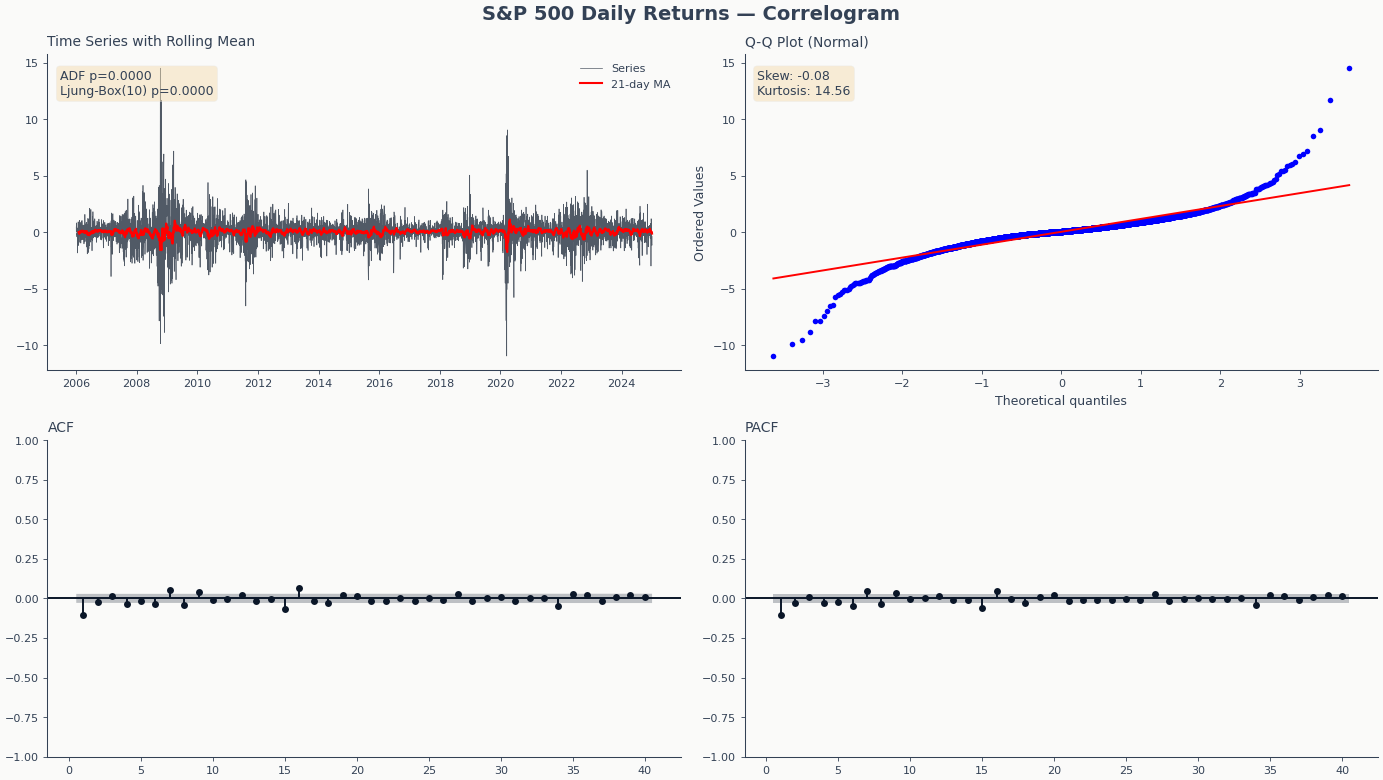

In [7]:
def plot_correlogram(series: pd.Series, title: str, lags: int = 40):
    """Create diagnostic correlogram: time series, Q-Q, ACF, PACF."""
    series = series.dropna()
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    ax = axes[0, 0]
    ax.plot(series.index, series.values, linewidth=0.5, alpha=0.7, label="Series")
    rolling_mean = series.rolling(21).mean()
    ax.plot(series.index, rolling_mean.values, linewidth=1.5, color="red", label="21-day MA")
    ax.set_title("Time Series with Rolling Mean")
    ax.legend()

    # Stats annotation
    adf_pval = adfuller(series, autolag="AIC")[1]
    ljung = acorr_ljungbox(series, lags=[10], return_df=True)
    lb_pval = ljung["lb_pvalue"].values[0]
    ax.text(
        0.02,
        0.95,
        f"ADF p={adf_pval:.4f}\nLjung-Box(10) p={lb_pval:.4f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    ax = axes[0, 1]
    probplot(series, dist="norm", plot=ax)
    ax.set_title("Q-Q Plot (Normal)")
    skew_val = series.skew()
    kurt_val = series.kurtosis()
    ax.text(
        0.02,
        0.95,
        f"Skew: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    ax = axes[1, 0]
    plot_acf(series, lags=lags, zero=False, ax=ax)
    ax.set_title("ACF")

    ax = axes[1, 1]
    plot_pacf(series, lags=lags, zero=False, ax=ax, method="ywm")
    ax.set_title("PACF")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig


fig = plot_correlogram(returns, "S&P 500 Daily Returns — Correlogram")
plt.show()

**Observations**: ACF and PACF stay close to zero at every lag, so any linear
dependence in raw returns is small in magnitude — even where formal tests
(below) detect it given the long sample. The Q-Q plot fans out at both ends,
consistent with fat tails and excess kurtosis well above the Gaussian baseline.

### ml4t-diagnostic: Autocorrelation Analysis with ARIMA Suggestion

`analyze_autocorrelation()` examines the ACF/PACF patterns and suggests
ARIMA orders — useful before fitting time series models in NB07.

In [8]:
acf_result = analyze_autocorrelation(returns.dropna().values)
print("=== ml4t-diagnostic: Autocorrelation Analysis ===")
print(f"Suggested ARIMA order: {acf_result.suggested_arima_order}")

2026-06-12 23:33:40,940 - ml4t.diagnostic.evaluation.autocorrelation - INFO - Starting autocorrelation analysis


2026-06-12 23:33:40,942 - ml4t.diagnostic.evaluation.autocorrelation - INFO - ACF computed (n_obs=4780 nlags=36 significant=10)


2026-06-12 23:33:40,946 - ml4t.diagnostic.evaluation.autocorrelation - INFO - PACF computed (n_obs=4780 nlags=36 significant=11)


2026-06-12 23:33:40,946 - ml4t.diagnostic.evaluation.autocorrelation - INFO - Autocorrelation analysis completed (arima_order=(2, 0, 1) white_noise=False)


=== ml4t-diagnostic: Autocorrelation Analysis ===
Suggested ARIMA order: (2, 0, 1)


## Ljung-Box Test

Formal test for whether the first $m$ autocorrelations are jointly zero.
Useful for checking model residuals.

In [9]:
lb_results = acorr_ljungbox(returns, lags=[5, 10, 20, 40], return_df=True)
lb_returns_reject = (lb_results["lb_pvalue"] < 0.05).any()
print(
    f"Returns: {'autocorrelation detected' if lb_returns_reject else 'no significant autocorrelation'}"
)
display(lb_results)

# Check squared returns (volatility clustering)
lb_sq = acorr_ljungbox(returns**2, lags=[5, 10, 20, 40], return_df=True)
lb_sq_reject = (lb_sq["lb_pvalue"] < 0.05).any()
print(f"Squared returns: {'ARCH effects present' if lb_sq_reject else 'no ARCH effects'}")
display(lb_sq)

Returns: autocorrelation detected


,lb_stat,lb_pvalue
5,59.861214,1.298427e-11
10,97.385513,1.815718e-16
20,149.584984,7.547474e-22
40,179.556515,1.369741e-19


Squared returns: ARCH effects present


,lb_stat,lb_pvalue
5,2397.216257,0.0
10,4095.474843,0.0
20,5971.346361,0.0
40,7427.790338,0.0


**Finding**: Highly significant Ljung-Box statistics on squared returns confirm
ARCH effects — volatility clusters in time. This motivates the GARCH models
developed in `08_garch_volatility`.

## Rolling Stationarity Features

Stationarity is not a fixed property — it can change over time. Rolling
ADF/KPSS statistics become time-varying features that detect when
relationships break down (e.g., cointegration weakening).

In [10]:
WINDOW = ROLLING_WINDOW  # From parameters cell
STEP = 5  # Compute every 5 days

rolling_stats = []

for end in range(WINDOW, len(returns), STEP):
    window_data = returns.iloc[end - WINDOW : end]
    try:
        adf_result = adfuller(window_data, autolag="AIC")
        kpss_result = kpss(window_data, regression="c", nlags="auto")
        adf_stat = adf_result[0]
        kpss_stat = kpss_result[0]

        # Decision: both agree on stationary?
        adf_reject = adf_result[1] < 0.05
        kpss_not_reject = kpss_result[1] > 0.05
        stationary = int(adf_reject and kpss_not_reject)

        rolling_stats.append(
            {
                "timestamp": returns.index[end],
                "adf_statistic": adf_stat,
                "kpss_statistic": kpss_stat,
                "stationarity_regime": stationary,
            }
        )
    except Exception:
        continue

rolling_df = pd.DataFrame(rolling_stats).set_index("timestamp")

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")


/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")


/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

...

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")


/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(window_data, regression="c", nlags="auto")
/tmp/ipykernel_1844253/2245296499.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than

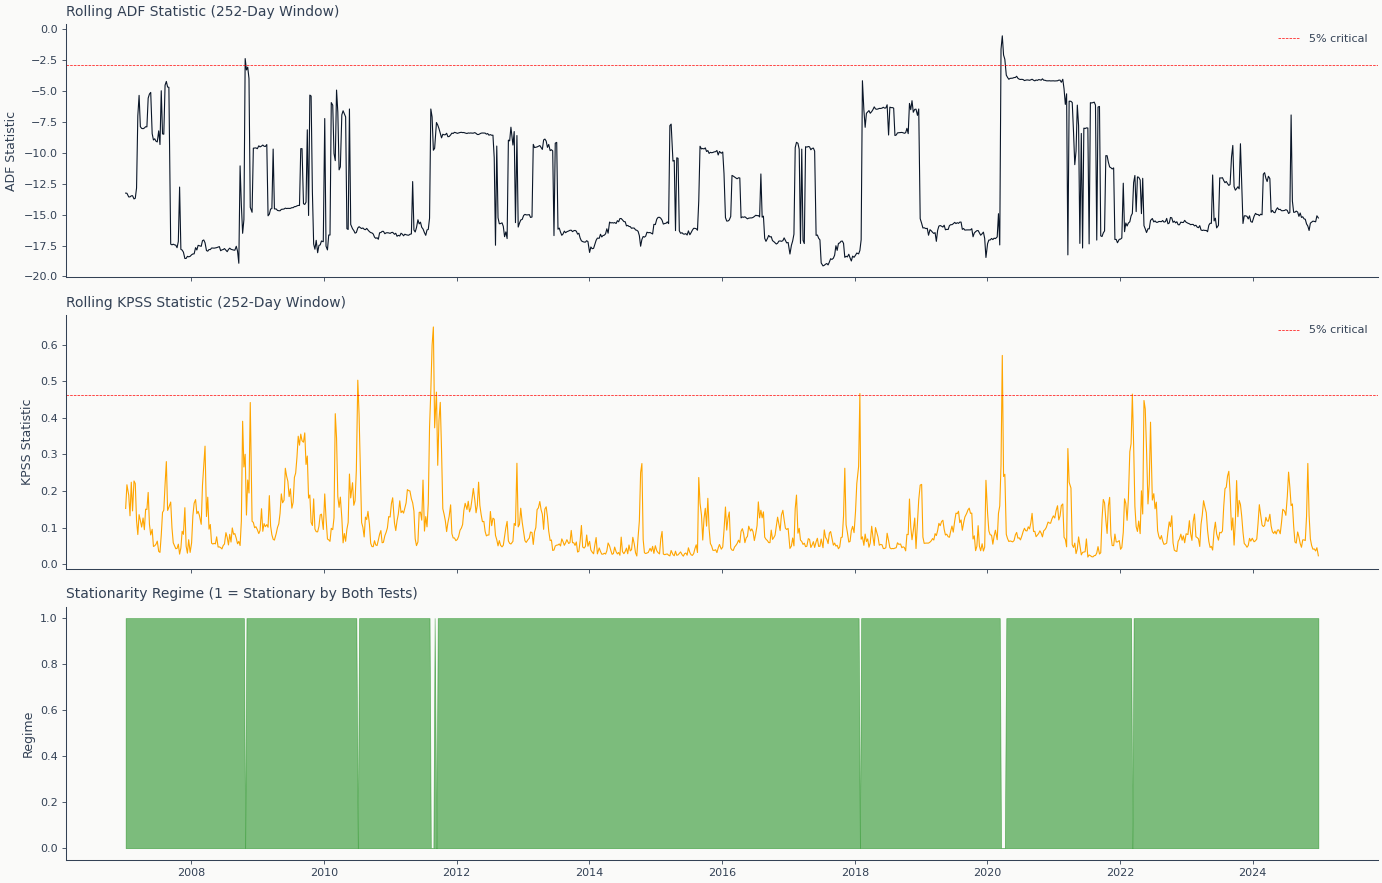

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(rolling_df.index, rolling_df["adf_statistic"], linewidth=0.8)
ax.axhline(-2.86, color="red", linestyle="--", linewidth=0.5, label="5% critical")
ax.set_title("Rolling ADF Statistic (252-Day Window)")
ax.set_ylabel("ADF Statistic")
ax.legend()

ax = axes[1]
ax.plot(rolling_df.index, rolling_df["kpss_statistic"], linewidth=0.8, color="orange")
ax.axhline(0.463, color="red", linestyle="--", linewidth=0.5, label="5% critical")
ax.set_title("Rolling KPSS Statistic (252-Day Window)")
ax.set_ylabel("KPSS Statistic")
ax.legend()

ax = axes[2]
ax.fill_between(rolling_df.index, 0, rolling_df["stationarity_regime"], alpha=0.5, color="green")
ax.set_title("Stationarity Regime (1 = Stationary by Both Tests)")
ax.set_ylabel("Regime")

plt.tight_layout()
plt.show()

## Distribution Analysis

Beyond stationarity and autocorrelation, the distribution of returns matters
for model selection: fat tails affect VaR, skewness affects directional bets,
and ARCH effects motivate GARCH models (NB08).

In [12]:
dist_result = analyze_distribution(returns.dropna().values)
print("=== ml4t-diagnostic: Distribution Analysis ===")
m = dist_result.moments_result
print(f"Mean: {m.mean:.4f}")
print(f"Std: {m.std:.4f}")
print(f"Skewness: {m.skewness:.4f}")
print(f"Excess kurtosis: {m.excess_kurtosis:.4f}")
print(f"Jarque-Bera p-value: {dist_result.jarque_bera_result.p_value:.6f}")
print(f"Normal: {dist_result.is_normal}")

2026-06-12 23:33:43,327 - ml4t.diagnostic.evaluation.distribution - INFO - Starting comprehensive distribution analysis (compute_tails=True alpha=0.05)


2026-06-12 23:33:43,327 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Computing distribution moments (n_obs=4780)


2026-06-12 23:33:43,327 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Computing distribution moments (n_obs=4780)


2026-06-12 23:33:43,329 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Moments computed (skewness=-0.08096319832510852 excess_kurtosis=14.564166268785257 skewness_sig=True excess_kurtosis_sig=True)


2026-06-12 23:33:43,329 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Moments computed (skewness=-0.08096319832510852 excess_kurtosis=14.564166268785257 skewness_sig=True excess_kurtosis_sig=True)


...

2026-06-12 23:33:43,335 - ml4t.diagnostic.evaluation.distribution.tails - INFO - QQ plot data generated (distribution=t r_squared=0.9930260811121839)


2026-06-12 23:33:43,336 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Tail analysis completed (tail_index=2.861623851699361 classification=medium best_fit=t)


2026-06-12 23:33:43,336 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Tail analysis completed (tail_index=2.861623851699361 classification=medium best_fit=t)


2026-06-12 23:33:43,336 - ml4t.diagnostic.evaluation.distribution - INFO - Distribution analysis completed (is_normal=False recommended=t n_obs=4780)


=== ml4t-diagnostic: Distribution Analysis ===
Mean: 0.0470
Std: 1.2210
Skewness: -0.0810
Excess kurtosis: 14.5642
Jarque-Bera p-value: 0.000000
Normal: False


**Interpretation**: Excess kurtosis >> 3 confirms fat tails (extreme returns
more frequent than normal); the Jarque-Bera test strongly rejects normality.
This motivates heavy-tailed distributions (Student-t) in GARCH models
and non-parametric approaches for VaR.

## ARCH Effects: Bridge to GARCH (NB08)

The Ljung-Box test on squared returns already suggested volatility clustering.
The formal ARCH-LM test confirms whether conditional heteroskedasticity is
present — the key prerequisite for GARCH modeling.

In [13]:
arch_result = arch_lm_test(returns.dropna().values)
print("=== ml4t-diagnostic: ARCH-LM Test ===")
print(f"Test statistic: {arch_result.test_statistic:.4f}")
print(f"P-value: {arch_result.p_value:.6f}")
print(f"ARCH effects: {arch_result.has_arch_effects}")

2026-06-12 23:33:43,374 - ml4t.diagnostic.evaluation.volatility.arch - INFO - ARCH-LM test complete: statistic=1478.2388, p-value=0.0000 (lags=12 n_obs=4780)


=== ml4t-diagnostic: ARCH-LM Test ===
Test statistic: 1478.2388
P-value: 0.000000
ARCH effects: True


**Bridge to NB08**: Strong ARCH effects confirm that constant-variance models
are inadequate. GARCH(1,1) is the natural next step — see `08_garch_volatility`
for fitting, diagnostics, and feature extraction.

## Feature Catalog: Diagnostic Features

| Feature | Source | Computation | Update |
|---------|--------|-------------|--------|
| `adf_statistic` | Unit root test | Rolling 252-day ADF | Weekly |
| `adf_pvalue` | Unit root test | P-value from ADF | Weekly |
| `kpss_statistic` | Unit root test | Rolling 252-day KPSS | Weekly |
| `stationarity_regime` | Combined | Joint decision matrix | Weekly |

## Key Takeaways

1. **Visual inspection first**: time series plot, ACF/PACF, Q-Q reveal
   trends, dependence, and distributional properties at a glance
2. **Use both ADF and KPSS**: opposite null hypotheses give robust
   conclusions via the decision matrix
3. **Returns are stationary, prices are not**: first-differencing is the
   standard fix, but fractional differencing preserves memory (see NB03)
4. **Squared returns show ARCH effects**: volatility clusters, motivating
   GARCH models (NB08)
5. **Rolling stationarity statistics** become time-varying features that
   detect regime changes in real time
6. **ml4t-diagnostic consolidates diagnostics**: `analyze_stationarity()`
   provides three-test consensus; `analyze_autocorrelation()` suggests ARIMA
   orders; `analyze_distribution()` and `arch_lm_test()` complete the
   pre-modeling diagnostic workflow

**Next**: See `02_structural_breaks` for break detection and
`03_fractional_differencing` for memory-preserving stationarity transforms.